In [1]:
from mnk import CreateEquations
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import numpy as np

# Исходные данные

In [31]:
data = [
    [[0.69],[14.0],[],[],[],[]],
    [[1.81],[11.7],[],[],[],[]],
    [[2.56],[10.4],[],[],[],[]],
    [[3.31],[9.4],[],[],[],[]],
    [[3.82],[8.6],[],[],[],[]],
    [[4.16],[8.1],[],[],[],[]],
    [[4.62],[7.4],[],[],[],[]],
    [[4.72],[7.1],[],[],[],[]],
    [[5.20],[6.4],[],[],[],[]],
    [[5.34],[6.0],[],[],[],[]],
    [[5.62],[5.8],[],[],[],[]],
    [[5.80],[5.5],[],[],[],[]],
    [[5.95],[5.2],[],[],[],[]],
    [[6.23],[5.0],[],[],[],[]],
    [[6.31],[4.7],[],[],[],[]]
]

# Результаты прямых измерений и их обработка

## Рассчёт параметров цепи

Возьмём напряжение и ток из таблицы

In [32]:
x = [i[1][0] for i in data]  # U
y = [i[0][0] for i in data]  # I

In [33]:
print(f"Avg U: {sum(x)/len(x)} В")
print(f"Avg I: {sum(y)/len(y)} мА")

Avg U: 7.6866666666666665 В
Avg I: 4.4093333333333335 мА


Создадим уравнения для МНК (A=rt+s)

In [34]:
equations = CreateEquations(x, y)()

Получим параметры МНК

In [35]:
s = equations.target_eq.shift
r = equations.target_eq.k

print(f"ЭДС источника s={s:.2f} В")
print(f"Внутреннее сопротивление r={r:.2f} В/мА")

ЭДС источника s=9.19 В
Внутреннее сопротивление r=-0.62 В/мА


Рисуем график

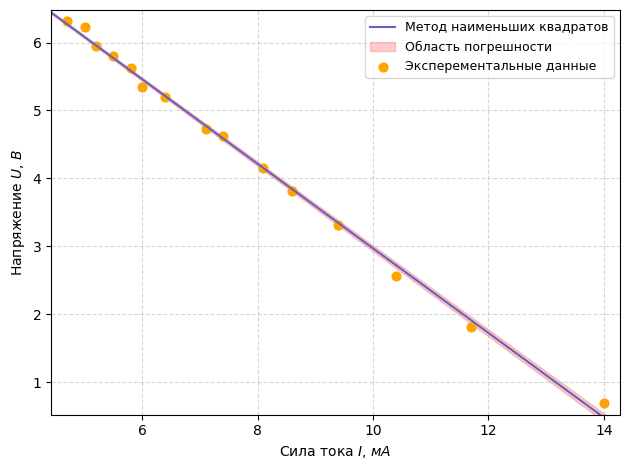

In [7]:
delta_x = abs(min(x)-max(x))
delta_y = abs(min(y)-max(y))
multiplier = 0.06

points = [min(x) - delta_x*multiplier, max(x) + delta_x*multiplier]


ax = plt.axes()
#ax.yaxis.set_minor_locator(MultipleLocator(0.01))
#ax.xaxis.set_minor_locator(MultipleLocator(5))
#ax.xaxis.set_major_locator(MultipleLocator(10))

ax.set_xlim(min(x) - delta_x*multiplier/2, max(x) + delta_x*multiplier/2)
ax.set_ylim(min(y) - delta_y*multiplier/2, max(y) + delta_y*multiplier/2)

# linear
plt.plot(
    points,
    [equations.target_eq(x) for x in points],
    color ="#6263c1",
    
    label='Метод наименьших квадратов'
)

# deviation
plt.fill_between(
    points,
    [equations.max_linear_eq(x) for x in points],
    [equations.min_linear_eq(x) for x in points],
    color='red',
    alpha=0.2,
    label='Область погрешности'
)

# points
plt.scatter(
    x,
    y,
    color='orange',
    s=40,
    marker='o',

    label='Эксперементальные данные'
)

# plot settings
plt.grid(True, alpha=0.5, linestyle='--', which='both')

plt.ylabel(r'Напряжение $U$, $В$', fontsize = 10)
plt.xlabel(r'Сила тока $I$, $мA$', fontsize = 10)

plt.legend(
    loc="upper right",
    fontsize=9
)
plt.tight_layout()

plt.savefig("img/plot_voltage_and_amperage.png", dpi=700)

plt.show()

## Нахождение мощностей

Возьмём напряжение и ток из таблицы

In [8]:
U = [i[0][0] for i in data]
I = [i[1][0] for i in data]

Посчитаем мощности и запишем в таблицу

In [9]:
for idx,(u,i) in enumerate(zip(U,I)):
    data[idx][2]=[u*i]                              # P_r - полезная мощность
    data[idx][3]=[-equations.target_eq.k*i**2]      # P_s - мощьность потерь
    data[idx][4]=[equations.target_eq.shift*i]      # P   - теоретическая мощность
    data[idx][5]=[data[idx][2][0]/data[idx][4][0]]  # nu  - кпд ({полезная мощность}/{теоретическая мощность})

Выведем typst-пригодную таблицу

In [10]:
for idx, line in enumerate(data):
    print(f"{[idx+1]}", end=", ")
    for elem in line:
        if len(elem) == 1:
            print(f"[{elem[0]:.2f}]" , end=", ")
        else:
            print("[]", end=", ")
    print()

[1], [0.69], [14.00], [9.66], [121.97], [128.70], [0.08], 
[2], [1.81], [11.70], [21.18], [85.19], [107.56], [0.20], 
[3], [2.56], [10.40], [26.62], [67.31], [95.61], [0.28], 
[4], [3.31], [9.40], [31.11], [54.99], [86.41], [0.36], 
[5], [3.82], [8.60], [32.85], [46.03], [79.06], [0.42], 
[6], [4.16], [8.10], [33.70], [40.83], [74.46], [0.45], 
[7], [4.62], [7.40], [34.19], [34.08], [68.03], [0.50], 
[8], [4.72], [7.10], [33.51], [31.37], [65.27], [0.51], 
[9], [5.20], [6.40], [33.28], [25.49], [58.83], [0.57], 
[10], [5.34], [6.00], [32.04], [22.40], [55.16], [0.58], 
[11], [5.62], [5.80], [32.60], [20.93], [53.32], [0.61], 
[12], [5.80], [5.50], [31.90], [18.83], [50.56], [0.63], 
[13], [5.95], [5.20], [30.94], [16.83], [47.80], [0.65], 
[14], [6.23], [5.00], [31.15], [15.56], [45.96], [0.68], 
[15], [6.31], [4.70], [29.66], [13.75], [43.21], [0.69], 


Построим графики мощностей

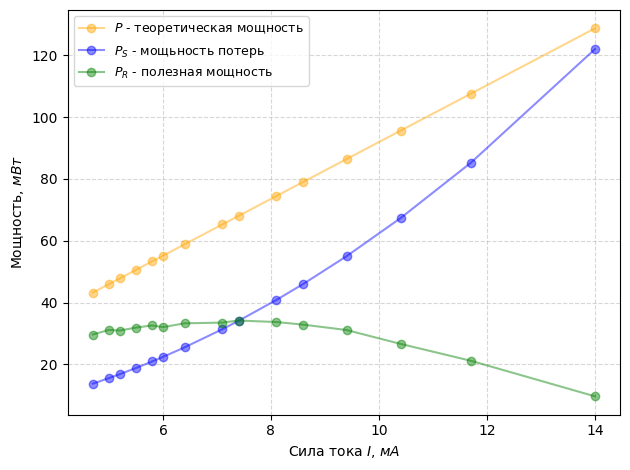

In [11]:
plt.close()

ax = plt.axes()
#ax.yaxis.set_minor_locator(MultipleLocator(100))
#ax.xaxis.set_minor_locator(MultipleLocator(10))


plt.plot(
    [i[1][0] for i in data],
    [i[4][0] for i in data],  # P - теоретическая мощность

    color='orange',
    marker='o',
    alpha=0.45,

    label=r'$P$ - теоретическая мощность'
)


plt.plot(
    [i[1][0] for i in data],
    [i[3][0] for i in data],  # P_s - мощьность потерь

    color='blue',
    marker='o',
    alpha=0.45,

    label=r'$P_S$ - мощьность потерь'
)


plt.plot(
    [i[1][0] for i in data],
    [i[2][0] for i in data],  # P_r - полезная мощность

    color='green',
    marker='o',
    alpha=0.45,

    label=r'$P_R$ - полезная мощность'
)


plt.grid(True, alpha=0.5, linestyle='--', which='both')

plt.ylabel(r'Мощность, $мВт$', fontsize = 10)
plt.xlabel(r'Сила тока $I$, $мA$', fontsize = 10)

plt.legend(
    loc="upper left",
    fontsize=9
)
plt.tight_layout()


plt.savefig("img/power_multiple.png", dpi=700)


plt.show()

Найдём макисмальную полезную мощность и ток при которой она достигается

In [12]:
P_R_max, I_star = max([(elem[2][0],elem[1][0]) for elem in data], key=lambda x: x[0])
print(f"Ток ари котором развивается макс. полезная мрщность I*={I_star:.2f} мА")
print(f"Развиваемая макс. полезная мощность P_R_max={P_R_max:.2f} Вт")

Ток ари котором развивается макс. полезная мрщность I*=7.40 мА
Развиваемая макс. полезная мощность P_R_max=34.19 Вт


Сопротивление при котором развивается макс. полезная мощность

In [13]:
R_max = P_R_max/(I_star**2)
Delta_R_max = abs(R_max - abs(r))
Epsylon_R_max = Delta_R_max/P_R_max

print(f"Сопротивление ари котором развивается макс. полезная мрщность R_max={R_max:.2f} В/мА")
print(f"Delta {Delta_R_max} В/мА")
print(f"Epsilon {Epsylon_R_max*100}%")

Сопротивление ари котором развивается макс. полезная мрщность R_max=0.62 В/мА
Delta 0.0020047360272655856 В/мА
Epsilon 0.0058638587436105815%


## КПД

Вытащим КПД и ток из таблицы

In [14]:
eta = [i[5][0] for i in data]
I = [i[1][0] for i in data]

In [15]:
print(f"Avg eta: {sum(eta)/len(eta)}")
print(f"Avg I: {sum(y)/len(y)} мА")

Avg eta: 0.4796457025679392
Avg I: 4.4093333333333335 мА


Создадим уравнения для МНК

In [16]:
equations = CreateEquations(I, eta)()

In [17]:
print(equations.target_eq.k)
print(equations.target_eq.shift)

-0.06769570218110071
1.0


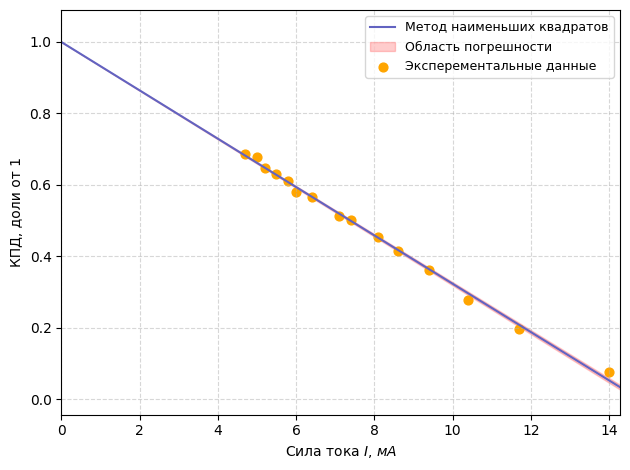

In [18]:
plt.close()

delta_eta = abs(min(eta)-max(eta))
delta_I = abs(min(I)-max(I))
multiplier = 0.06

ax = plt.axes()

points = [0 - delta_I*multiplier, max(x) + delta_I*multiplier]
ax.set_xlim(0, max(x) + delta_I*multiplier/2)

#ax.yaxis.set_minor_locator(MultipleLocator(0.01))
#ax.xaxis.set_minor_locator(MultipleLocator(5))
#ax.xaxis.set_major_locator(MultipleLocator(10))

# linear
plt.plot(
    points,
    [equations.target_eq(x) for x in points],
    color ="#6263c1",
    
    label='Метод наименьших квадратов'
)

# deviation
plt.fill_between(
    points,
    [equations.max_linear_eq(x) for x in points],
    [equations.min_linear_eq(x) for x in points],
    color='red',
    alpha=0.2,
    label='Область погрешности'
)

# points
plt.scatter(
    I,
    eta,
    color='orange',
    s=40,
    marker='o',

    label='Эксперементальные данные'
)



plt.grid(True, alpha=0.5, linestyle='--', which='both')

plt.ylabel(r'КПД, доли от 1', fontsize = 10)
plt.xlabel(r'Сила тока $I$, $мA$', fontsize = 10)

plt.legend(
    loc="upper right",
    fontsize=9
)
plt.tight_layout()


plt.savefig("img/kpd_and_amperage.png", dpi=700)


plt.show()

Обратный рассчёт - при каком токе КПД будет 50%

In [19]:
_ = lambda eta: (eta - equations.target_eq.shift)/equations.target_eq.k
I_star_0_5 = _(0.5)

print(f"{_(0.5)} мА")

7.385993259400594 мА


In [20]:
print(abs(I_star_0_5 - I_star))
print(abs(I_star_0_5 - I_star)/I_star*100)

0.014006740599405987
0.18928027837035116


# Погрешности

In [40]:
Delta_r = 2 * (
    sum([
        (U_i - (s - I_i*abs(r)))**2
        for U_i, I_i in zip(U,I)
    ])/
    ((len(data)-2)*sum([(I_i - sum(I)/len(I))**2 for I_i in I]))
)**0.5
print("Delta_r:", Delta_r)
Epsilon_r = Delta_r/abs(r)*100
print("Epsilon_r:", Epsilon_r)

Delta_r: 0.01942477203326284
Epsilon_r: 3.1213499299319176


In [47]:
n = len(data)
I_avg = sum(I) / n

# 1. Сумма квадратов остатков: Σ(U_i - (ε - r·I_i))²
#    Здесь r положительное, поэтому ε - r·I_i
residuals_sq_sum = sum((U[i] - (s - abs(r) * I[i]))**2 for i in range(n))

# 2. Сумма квадратов отклонений тока: Σ(I_i - Ī)²
I_dev_sq_sum = sum((I[i] - I_avg)**2 for i in range(n))

# 3. Первое слагаемое под корнем: (1/n)
term1 = 1 / n

# 4. Второе слагаемое под корнем: Ī² / Σ(I_i - Ī)²
term2 = I_avg**2 / I_dev_sq_sum

# 5. Множитель: Σ(U_i - (ε - r·I_i))² / (n-2)
factor = residuals_sq_sum / (n - 2)

# 6. Все под корнем: factor * (term1 + term2)
under_root = factor * (term1 + term2)

# 7. Результат: 2 * √(under_root)
Delta_epsilon = 2 * (under_root)**0.5

print(Delta_epsilon)
print(Delta_epsilon/s*100)

0.1577382390587128
1.7158709214199996


In [ ]:

# 1. Сумма квадратов остатков: Σ(U_i - (ε - r·I_i))²
#    Здесь r положительное, поэтому ε - r·I_i
residuals_sq_sum = sum((U[i] - (epsilon - r * I[i]))**2 for i in range(n))

# 2. Сумма квадратов отклонений тока: Σ(I_i - Ī)²
I_dev_sq_sum = sum((I[i] - I_avg)**2 for i in range(n))

# 3. Первое слагаемое под корнем: (1/n)
term1 = 1 / n

# 4. Второе слагаемое под корнем: Ī² / Σ(I_i - Ī)²
term2 = I_avg**2 / I_dev_sq_sum

# 5. Множитель: Σ(U_i - (ε - r·I_i))² / (n-2)
factor = residuals_sq_sum / (n - 2)

# 6. Все под корнем: factor * (term1 + term2)
under_root = factor * (term1 + term2)

# 7. Результат: 2 * √(under_root)
Delta_epsilon = 2 * math.sqrt(under_root)